In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Load datasets
print("Loading datasets...")

try:
    games = pd.read_csv('../data/games.csv')
    recommendations = pd.read_csv('../data/recommendations.csv')
    users = pd.read_csv('../data/users.csv')
    
    print(f"✓ Games: {games.shape}")
    print(f"✓ Recommendations: {recommendations.shape}")
    print(f"✓ Users: {users.shape}")
    print("\n✓ All datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Make sure CSV files are in the 'data' folder!")

Loading datasets...
✓ Games: (50872, 13)
✓ Recommendations: (41154794, 8)
✓ Users: (14306064, 3)

✓ All datasets loaded successfully!


In [3]:
print("="*60)
print("GAMES DATASET - BASIC INFO")
print("="*60)

print("\n📋 First 5 rows:")
display(games.head())

print("\n📊 Data types:")
print(games.dtypes)

print("\n🔍 Dataset shape:")
print(f"Rows: {games.shape[0]:,}")
print(f"Columns: {games.shape[1]}")

print("\n❓ Missing values:")
missing = games.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("No missing values!")

print("\n📈 Basic statistics:")
display(games.describe())

GAMES DATASET - BASIC INFO

📋 First 5 rows:


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True



📊 Data types:
app_id              int64
title                 str
date_release          str
win                  bool
mac                  bool
linux                bool
rating                str
positive_ratio      int64
user_reviews        int64
price_final       float64
price_original    float64
discount          float64
steam_deck           bool
dtype: object

🔍 Dataset shape:
Rows: 50,872
Columns: 13

❓ Missing values:
No missing values!

📈 Basic statistics:


,app_id,positive_ratio,user_reviews,price_final,price_original,discount
count,5.087200e+04,50872.000000,5.087200e+04,50872.000000,50872.000000,50872.000000
mean,1.055224e+06,77.052033,1.824425e+03,8.620325,8.726788,5.592212
std,6.103249e+05,18.253592,4.007352e+04,11.514164,11.507021,18.606679
min,1.000000e+01,0.000000,1.000000e+01,0.000000,0.000000,0.000000
25%,5.287375e+05,67.000000,1.900000e+01,0.990000,0.990000,0.000000
50%,9.860850e+05,81.000000,4.900000e+01,4.990000,4.990000,0.000000
75%,1.524895e+06,91.000000,2.060000e+02,10.990000,11.990000,0.000000
max,2.599300e+06,100.000000,7.494460e+06,299.990000,299.990000,90.000000


RATING ANALYSIS


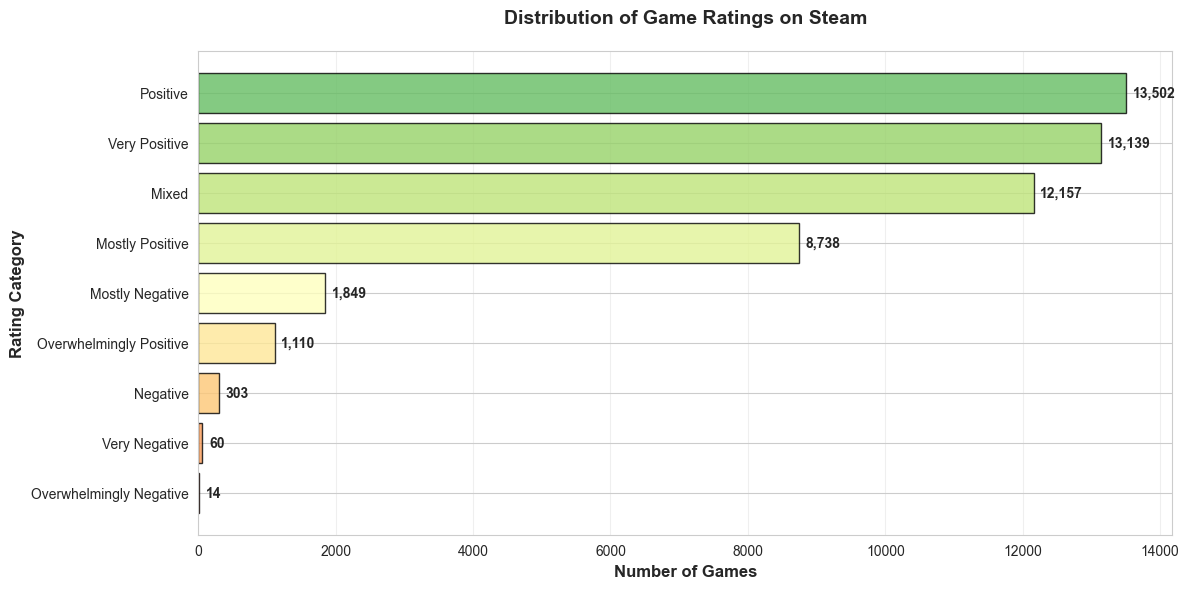


📊 Rating distribution:
Overwhelmingly Negative: 14 games (0.0%)
Very Negative: 60 games (0.1%)
Negative: 303 games (0.6%)
Overwhelmingly Positive: 1,110 games (2.2%)
Mostly Negative: 1,849 games (3.6%)
Mostly Positive: 8,738 games (17.2%)
Mixed: 12,157 games (23.9%)
Very Positive: 13,139 games (25.8%)
Positive: 13,502 games (26.5%)


In [4]:
print("="*60)
print("RATING ANALYSIS")
print("="*60)

# Rating distribution
plt.figure(figsize=(12, 6))
rating_counts = games['rating'].value_counts().sort_values(ascending=True)

# Create horizontal bar chart
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(rating_counts)))
bars = plt.barh(range(len(rating_counts)), rating_counts.values, color=colors, edgecolor='black', alpha=0.8)

plt.yticks(range(len(rating_counts)), rating_counts.index)
plt.xlabel('Number of Games', fontsize=12, fontweight='bold')
plt.ylabel('Rating Category', fontsize=12, fontweight='bold')
plt.title('Distribution of Game Ratings on Steam', fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, rating_counts.values)):
    plt.text(value + 100, i, f'{value:,}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Rating distribution:")
for rating, count in rating_counts.items():
    percentage = (count / len(games)) * 100
    print(f"{rating}: {count:,} games ({percentage:.1f}%)")

PRICE ANALYSIS

💰 Free games: 10,090 (19.8%)
💵 Paid games: 40,782 (80.2%)

📊 Price statistics (paid games only):
Average price: $10.89
Median price: $7.99
Min price: $0.50
Max price: $299.99


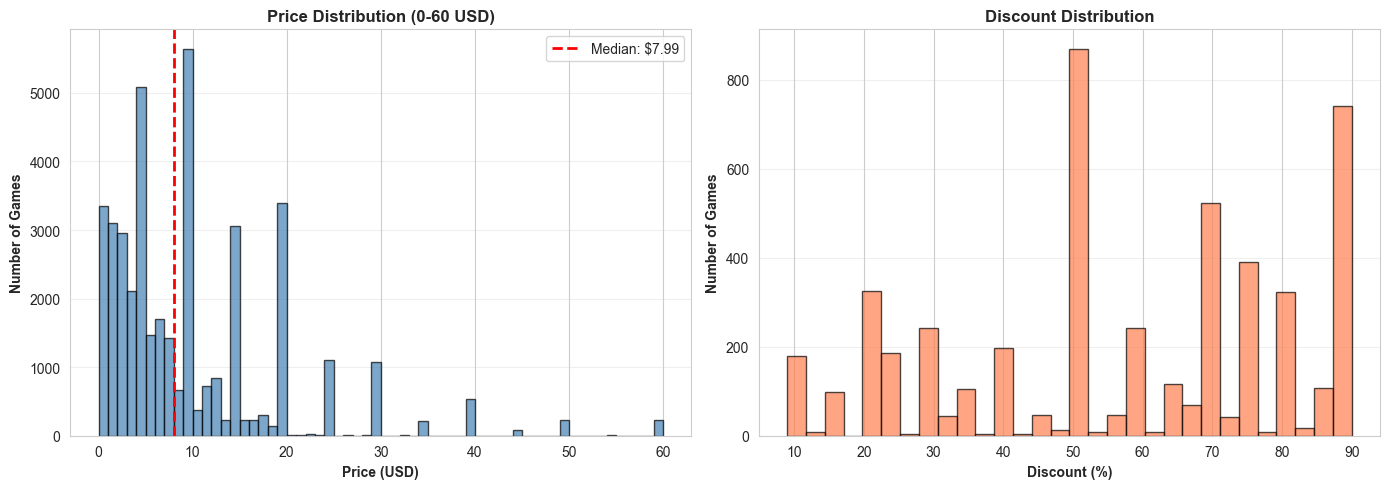


🎁 Games with discount: 4,969 (9.8%)
Average discount: 57.3%
Max discount: 90%


In [5]:
print("="*60)
print("PRICE ANALYSIS")
print("="*60)

# Separate free and paid games
free_games = games[games['price_original'] == 0]
paid_games = games[games['price_original'] > 0]

print(f"\n💰 Free games: {len(free_games):,} ({len(free_games)/len(games)*100:.1f}%)")
print(f"💵 Paid games: {len(paid_games):,} ({len(paid_games)/len(games)*100:.1f}%)")

if len(paid_games) > 0:
    print(f"\n📊 Price statistics (paid games only):")
    print(f"Average price: ${paid_games['price_original'].mean():.2f}")
    print(f"Median price: ${paid_games['price_original'].median():.2f}")
    print(f"Min price: ${paid_games['price_original'].min():.2f}")
    print(f"Max price: ${paid_games['price_original'].max():.2f}")

# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (0-60 USD range - most games are here)
axes[0].hist(paid_games['price_original'], bins=60, range=(0, 60), 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Price Distribution (0-60 USD)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Price (USD)', fontweight='bold')
axes[0].set_ylabel('Number of Games', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(paid_games['price_original'].median(), color='red', 
                linestyle='--', linewidth=2, label=f'Median: ${paid_games["price_original"].median():.2f}')
axes[0].legend()

# Discount distribution
games_with_discount = games[games['discount'] > 0]
axes[1].hist(games_with_discount['discount'], bins=30, edgecolor='black', 
             alpha=0.7, color='coral')
axes[1].set_title('Discount Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Discount (%)', fontweight='bold')
axes[1].set_ylabel('Number of Games', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎁 Games with discount: {len(games_with_discount):,} ({len(games_with_discount)/len(games)*100:.1f}%)")
if len(games_with_discount) > 0:
    print(f"Average discount: {games_with_discount['discount'].mean():.1f}%")
    print(f"Max discount: {games_with_discount['discount'].max():.0f}%")

PLATFORM SUPPORT ANALYSIS


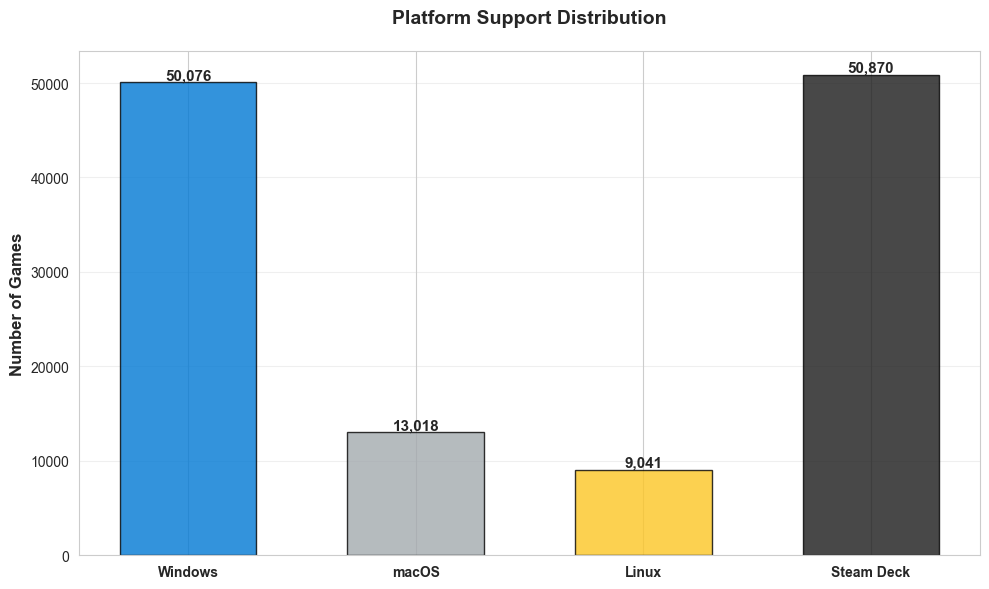


🖥️ Platform support breakdown:
Windows     : 50,076 games ( 98.4%)
macOS       : 13,018 games ( 25.6%)
Linux       :  9,041 games ( 17.8%)
Steam Deck  : 50,870 games (100.0%)

🌐 Multi-platform support:
2+ platforms: 0 games (0.0%)
All 3 platforms: 7,653 games (15.0%)


In [6]:
print("="*60)
print("PLATFORM SUPPORT ANALYSIS")
print("="*60)

# Calculate platform support
platforms = {
    'Windows': games['win'].sum(),
    'macOS': games['mac'].sum(),
    'Linux': games['linux'].sum(),
    'Steam Deck': games['steam_deck'].sum()
}

# Visualize
plt.figure(figsize=(10, 6))
colors = ['#0078D4', '#A3AAAE', '#FCC624', '#1A1A1A']
bars = plt.bar(platforms.keys(), platforms.values(), color=colors, 
               edgecolor='black', alpha=0.8, width=0.6)

plt.title('Platform Support Distribution', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of Games', fontweight='bold', fontsize=12)
plt.xticks(fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n🖥️ Platform support breakdown:")
for platform, count in platforms.items():
    percentage = (count / len(games)) * 100
    print(f"{platform:12s}: {count:6,} games ({percentage:5.1f}%)")

# Multi-platform support
print("\n🌐 Multi-platform support:")
multi_platform_count = games[(games['win'] + games['mac'] + games['linux']) >= 2].shape[0]
all_platform_count = games[(games['win'] == 1) & (games['mac'] == 1) & (games['linux'] == 1)].shape[0]
print(f"2+ platforms: {multi_platform_count:,} games ({multi_platform_count/len(games)*100:.1f}%)")
print(f"All 3 platforms: {all_platform_count:,} games ({all_platform_count/len(games)*100:.1f}%)")

TOP GAMES ANALYSIS


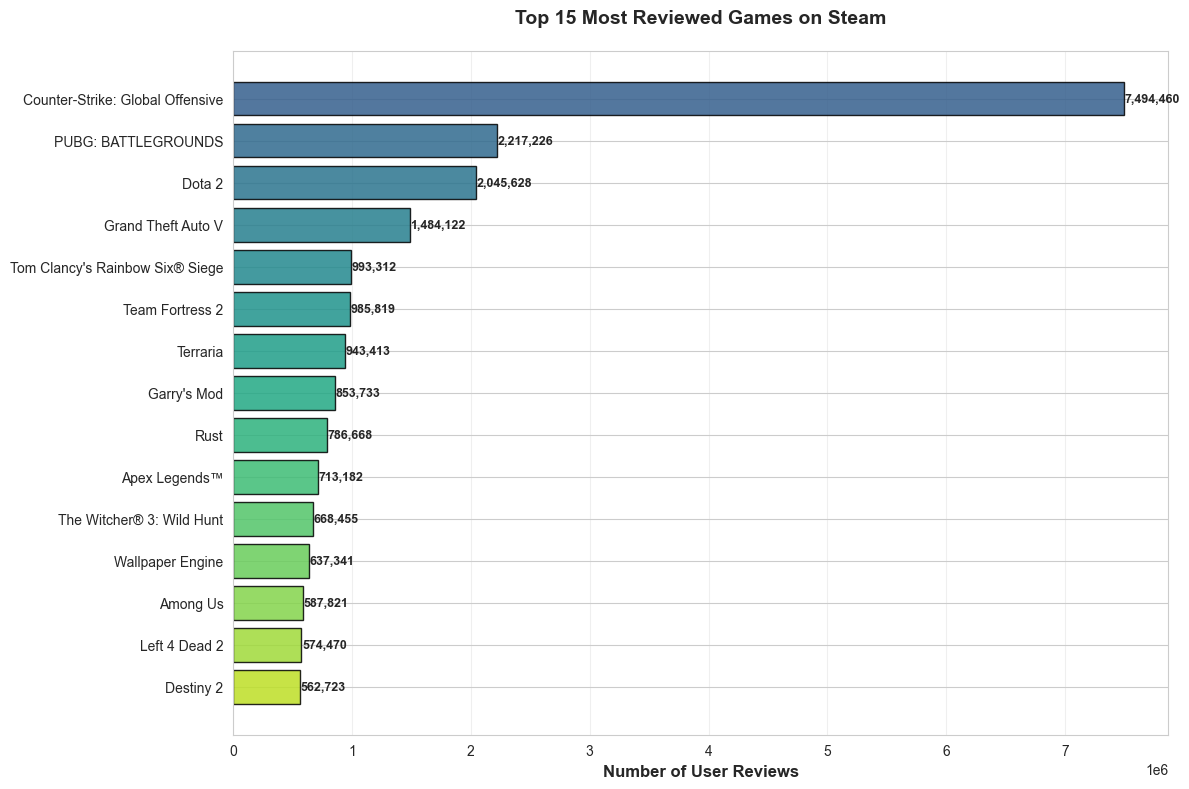


🏆 Top 15 Most Reviewed Games:
                           title  user_reviews                  rating  positive_ratio  price_original
Counter-Strike: Global Offensive       7494460           Very Positive              88             0.0
             PUBG: BATTLEGROUNDS       2217226                   Mixed              57             0.0
                          Dota 2       2045628           Very Positive              82             0.0
              Grand Theft Auto V       1484122           Very Positive              86             0.0
 Tom Clancy's Rainbow Six® Siege        993312           Very Positive              86             0.0
                 Team Fortress 2        985819           Very Positive              93             0.0
                        Terraria        943413 Overwhelmingly Positive              97             0.0
                     Garry's Mod        853733 Overwhelmingly Positive              96             0.0
                            Rust        78

In [7]:
print("="*60)
print("TOP GAMES ANALYSIS")
print("="*60)

# Top 15 most reviewed games
top_reviewed = games.nlargest(15, 'user_reviews')[['title', 'user_reviews', 'rating', 'positive_ratio', 'price_original']]

plt.figure(figsize=(12, 8))
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_reviewed)))
bars = plt.barh(range(len(top_reviewed)), top_reviewed['user_reviews'].values, 
                color=colors_gradient, edgecolor='black', alpha=0.85)

plt.yticks(range(len(top_reviewed)), top_reviewed['title'].values, fontsize=10)
plt.xlabel('Number of User Reviews', fontweight='bold', fontsize=12)
plt.title('Top 15 Most Reviewed Games on Steam', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_reviewed['user_reviews'].values)):
    plt.text(value + 5000, i, f'{value:,}', va='center', fontsize=9, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🏆 Top 15 Most Reviewed Games:")
print(top_reviewed.to_string(index=False))

In [8]:
print("="*60)
print("RECOMMENDATIONS DATASET")
print("="*60)

print("\n📋 First 5 rows:")
display(recommendations.head())

print("\n📊 Dataset info:")
print(f"Total recommendations: {len(recommendations):,}")
print(f"Unique users: {recommendations['user_id'].nunique():,}")
print(f"Unique games: {recommendations['app_id'].nunique():,}")

print("\n👍 Recommendation breakdown:")
positive = recommendations['is_recommended'].sum()
negative = len(recommendations) - positive
print(f"Positive (Recommended): {positive:,} ({positive/len(recommendations)*100:.1f}%)")
print(f"Negative (Not Recommended): {negative:,} ({negative/len(recommendations)*100:.1f}%)")

print("\n❓ Missing values:")
missing_recs = recommendations.isnull().sum()
missing_recs = missing_recs[missing_recs > 0]
if len(missing_recs) > 0:
    print(missing_recs)
else:
    print("No missing values!")

RECOMMENDATIONS DATASET

📋 First 5 rows:


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4



📊 Dataset info:
Total recommendations: 41,154,794
Unique users: 13,781,059
Unique games: 37,610

👍 Recommendation breakdown:
Positive (Recommended): 35,304,398 (85.8%)
Negative (Not Recommended): 5,850,396 (14.2%)

❓ Missing values:
No missing values!


HOURS PLAYED ANALYSIS

⏱️ Hours played statistics:
Overall average: 100.60 hours
Recommended games: 103.87 hours
Not recommended games: 80.89 hours
Median (overall): 27.30 hours


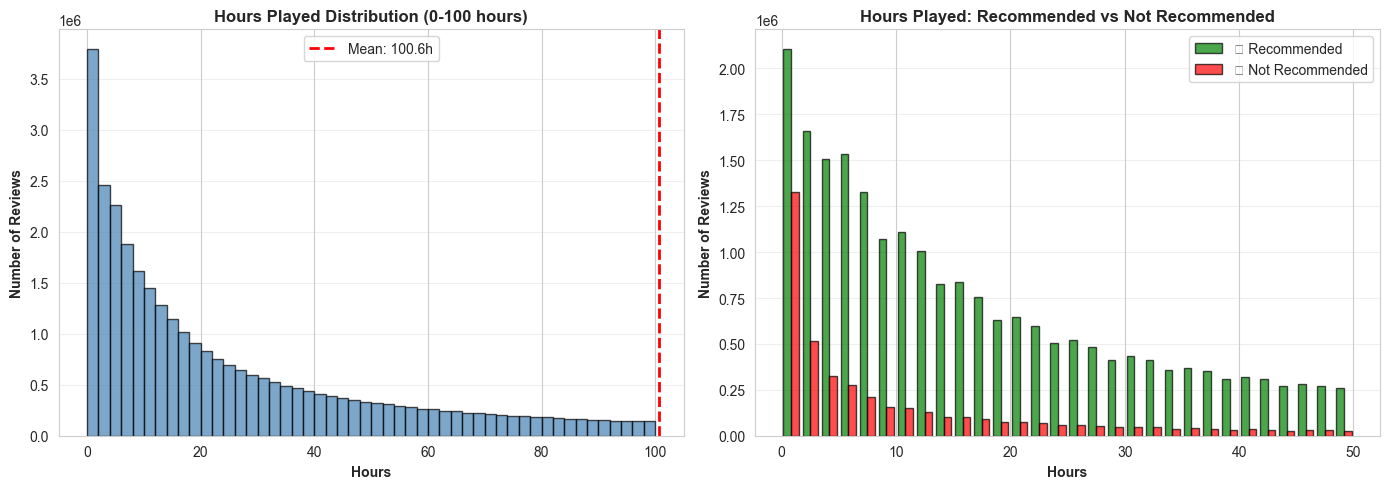


📊 Hours played quartiles:
25%     7.8
50%    27.3
75%    99.2
Name: hours, dtype: float64


In [9]:
print("="*60)
print("HOURS PLAYED ANALYSIS")
print("="*60)

# Separate by recommendation status
recommended = recommendations[recommendations['is_recommended']]
not_recommended = recommendations[~recommendations['is_recommended']]

print(f"\n⏱️ Hours played statistics:")
print(f"Overall average: {recommendations['hours'].mean():.2f} hours")
print(f"Recommended games: {recommended['hours'].mean():.2f} hours")
print(f"Not recommended games: {not_recommended['hours'].mean():.2f} hours")
print(f"Median (overall): {recommendations['hours'].median():.2f} hours")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution (0-100 hours)
axes[0].hist(recommendations['hours'], bins=50, range=(0, 100), 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Hours Played Distribution (0-100 hours)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hours', fontweight='bold')
axes[0].set_ylabel('Number of Reviews', fontweight='bold')
axes[0].axvline(recommendations['hours'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {recommendations["hours"].mean():.1f}h')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# By recommendation status
axes[1].hist([recommended['hours'], not_recommended['hours']], 
             bins=30, range=(0, 50),
             label=['👍 Recommended', '👎 Not Recommended'],
             alpha=0.7, edgecolor='black', color=['green', 'red'])
axes[1].set_title('Hours Played: Recommended vs Not Recommended', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Hours', fontweight='bold')
axes[1].set_ylabel('Number of Reviews', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional insights
print(f"\n📊 Hours played quartiles:")
print(recommendations['hours'].describe()[['25%', '50%', '75%']])

USERS DATASET

📋 First 5 rows:


,user_id,products,reviews
0,7360263,359,0
1,14020781,156,1
2,8762579,329,4
3,4820647,176,4
4,5167327,98,2



📊 User statistics:
Total users: 14,306,064

Products owned:
  Average: 116.37
  Median: 55
  Max: 32,214

Reviews written:
  Users with reviews: 13,781,059 (96.3%)
  Average (if > 0): 2.99
  Max: 6,045


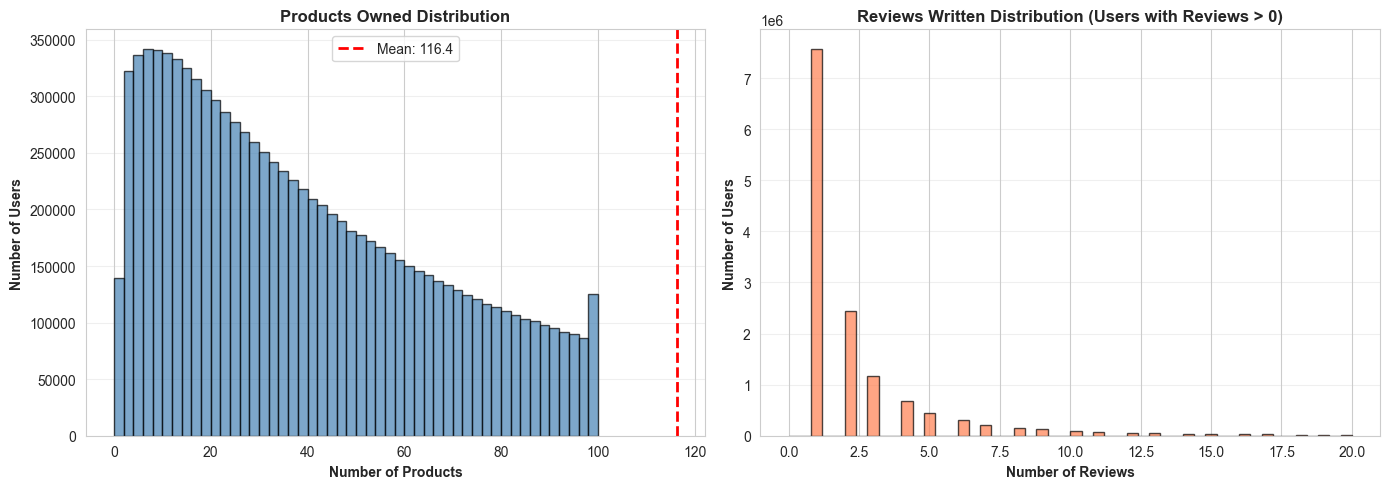

In [10]:
print("="*60)
print("USERS DATASET")
print("="*60)

print("\n📋 First 5 rows:")
display(users.head())

print("\n📊 User statistics:")
print(f"Total users: {len(users):,}")
print(f"\nProducts owned:")
print(f"  Average: {users['products'].mean():.2f}")
print(f"  Median: {users['products'].median():.0f}")
print(f"  Max: {users['products'].max():,}")

print(f"\nReviews written:")
users_with_reviews = users[users['reviews'] > 0]
print(f"  Users with reviews: {len(users_with_reviews):,} ({len(users_with_reviews)/len(users)*100:.1f}%)")
print(f"  Average (if > 0): {users_with_reviews['reviews'].mean():.2f}")
print(f"  Max: {users['reviews'].max():,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Products owned (0-100 range)
axes[0].hist(users['products'], bins=50, range=(0, 100), 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Products Owned Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Products', fontweight='bold')
axes[0].set_ylabel('Number of Users', fontweight='bold')
axes[0].axvline(users['products'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {users["products"].mean():.1f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Reviews written (only users with reviews > 0)
axes[1].hist(users_with_reviews['reviews'], bins=50, range=(0, 20),
             edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Reviews Written Distribution (Users with Reviews > 0)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Reviews', fontweight='bold')
axes[1].set_ylabel('Number of Users', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print("="*60)
print("SAVING KEY INSIGHTS")
print("="*60)

# Calculate key insights
insights = {
    'total_games': int(games.shape[0]),
    'total_users': int(users.shape[0]),
    'total_recommendations': int(recommendations.shape[0]),
    'unique_users_with_reviews': int(recommendations['user_id'].nunique()),
    'unique_games_reviewed': int(recommendations['app_id'].nunique()),
    'positive_recommendation_ratio': float(recommendations['is_recommended'].mean()),
    'avg_game_price': float(games[games['price_original'] > 0]['price_original'].mean()),
    'free_games_count': int((games['price_original'] == 0).sum()),
    'paid_games_count': int((games['price_original'] > 0).sum()),
    'windows_support': int(games['win'].sum()),
    'mac_support': int(games['mac'].sum()),
    'linux_support': int(games['linux'].sum()),
    'steam_deck_support': int(games['steam_deck'].sum()),
    'avg_hours_played': float(recommendations['hours'].mean()),
    'most_common_rating': str(games['rating'].value_counts().index[0])
}

print("\n📊 KEY INSIGHTS:")
print("-" * 60)
for key, value in insights.items():
    print(f"{key:35s}: {value}")

# Save to JSON
import json
with open('../data/eda_insights.json', 'w', encoding='utf-8') as f:
    json.dump(insights, f, indent=4, ensure_ascii=False)

print("\n✅ Insights saved to: data/eda_insights.json")

SAVING KEY INSIGHTS

📊 KEY INSIGHTS:
------------------------------------------------------------
total_games                        : 50872
total_users                        : 14306064
total_recommendations              : 41154794
unique_users_with_reviews          : 13781059
unique_games_reviewed              : 37610
positive_recommendation_ratio      : 0.8578441189621797
avg_game_price                     : 10.885909715070376
free_games_count                   : 10090
paid_games_count                   : 40782
windows_support                    : 50076
mac_support                        : 13018
linux_support                      : 9041
steam_deck_support                 : 50870
avg_hours_played                   : 100.60223780004829
most_common_rating                 : Positive

✅ Insights saved to: data/eda_insights.json


In [12]:
print("="*60)
print("EDA SUMMARY & NEXT STEPS")
print("="*60)

print("""
✅ EDA COMPLETED!

📊 Key Findings:
1. Dataset has {total_games:,} games, {total_users:,} users, and {total_recs:,} recommendations
2. {pos_ratio:.1%} of recommendations are positive
3. Most games ({win_pct:.1%}) support Windows
4. Average playtime is {avg_hours:.1f} hours
5. Free games account for {free_pct:.1%} of all games

🎯 Next Steps:
1. Feature Engineering - Create features for ML models
2. Data Preprocessing - Handle missing values, encoding
3. Train Traditional Model - Random Forest + Cosine Similarity
4. Train Deep Learning Model - MLP (Multi-Layer Perceptron)
5. Model Evaluation - Compare performance

📝 Notes for modeling:
- Need to handle imbalanced data (positive vs negative recommendations)
- Consider using user history features (products owned, past reviews)
- Game features: rating, price, platform support, positive_ratio
- User-game interaction: hours played, helpfulness, funny votes
""".format(
    total_games=len(games),
    total_users=len(users),
    total_recs=len(recommendations),
    pos_ratio=recommendations['is_recommended'].mean(),
    win_pct=games['win'].sum() / len(games),
    avg_hours=recommendations['hours'].mean(),
    free_pct=(games['price_original'] == 0).sum() / len(games)
))

print("="*60)
print("🎉 Ready to move to Feature Engineering!")
print("="*60)

EDA SUMMARY & NEXT STEPS

✅ EDA COMPLETED!

📊 Key Findings:
1. Dataset has 50,872 games, 14,306,064 users, and 41,154,794 recommendations
2. 85.8% of recommendations are positive
3. Most games (98.4%) support Windows
4. Average playtime is 100.6 hours
5. Free games account for 19.8% of all games

🎯 Next Steps:
1. Feature Engineering - Create features for ML models
2. Data Preprocessing - Handle missing values, encoding
3. Train Traditional Model - Random Forest + Cosine Similarity
4. Train Deep Learning Model - MLP (Multi-Layer Perceptron)
5. Model Evaluation - Compare performance

📝 Notes for modeling:
- Need to handle imbalanced data (positive vs negative recommendations)
- Consider using user history features (products owned, past reviews)
- Game features: rating, price, platform support, positive_ratio
- User-game interaction: hours played, helpfulness, funny votes

🎉 Ready to move to Feature Engineering!
